# Day 15 — Feature importance

Which of the 12 features do the Random Forest and XGBoost models actually use, and does that use hold up on unseen (validation) data? Test set untouched.

In [1]:
import os 

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.ensemble import RandomForestClassifier

from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

from idxlab.clean import clean_ticker_data
from idxlab.config import load_config
from idxlab.data import DataLoader
from idxlab.logging_setup import setup_logging
from idxlab.split import build_dataset, time_based_split

Path("docs/results").mkdir(parents=True, exist_ok=True)
Path("docs/figures").mkdir(parents=True, exist_ok=True)

c:\Semester 7\Project Iseng\IDX-ML-Lab\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cfg = load_config()
setup_logging(cfg.log_level)

raw = DataLoader.from_config(cfg).load_all()
bbca = clean_ticker_data(raw["BBCA.JK"])

dataset = build_dataset(bbca, horizon=1)
splits = time_based_split(dataset, train_size=0.7, val_size=0.15)

LABEL_COLUMNS = ["forward_return", "direction"]
feature_cols = [c for c in dataset if c not in LABEL_COLUMNS]

assert len(feature_cols) == 12
assert not set(LABEL_COLUMNS) & set(feature_cols), "label bocor ke fitur!"

X_train, y_train = splits.train[feature_cols], splits.train["direction"].astype(int)
X_val, y_val = splits.val[feature_cols], splits.val["direction"].astype(int)




09:59:40 | INFO     | idxlab.data | Cache hit for BBCA.JK (data\raw\BBCA_JK.parquet)
09:59:40 | INFO     | idxlab.data | Cache hit for BBRI.JK (data\raw\BBRI_JK.parquet)
09:59:40 | INFO     | idxlab.data | Cache hit for TLKM.JK (data\raw\TLKM_JK.parquet)
09:59:40 | INFO     | idxlab.data | Cache hit for ASII.JK (data\raw\ASII_JK.parquet)
09:59:40 | INFO     | idxlab.data | Cache hit for UNVR.JK (data\raw\UNVR_JK.parquet)


In [3]:
rf_params = dict(
    n_estimators=300, max_depth=5, min_samples_leaf=10, random_state=42, n_jobs=-1
)
rf = RandomForestClassifier(**rf_params).fit(X_train, y_train)

xgb = XGBClassifier(
    n_estimators=300, max_depth=3, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=42, n_jobs=-1,
).fit(X_train, y_train)

## 1. Built-in importance (computed on train)

In [4]:

builtin = pd.DataFrame({
    "rf": pd.Series(rf.feature_importances_, index=feature_cols),
    "xgb": pd.Series(xgb.feature_importances_, index=feature_cols),
})

print(builtin.sum().round(3))   # tiap kolom kira-kira berjumlah 1: ini porsi, bukan skor mentah
builtin.sort_values("rf", ascending=False).round(3)

rf     1.0
xgb    1.0
dtype: float64


,rf,xgb
rsi,0.123,0.092
bb_lower,0.120,0.100
macd_histogram,0.106,0.088
momentum,0.091,0.085
atr,0.081,0.081
sma,0.076,0.078
macd,0.075,0.085
bb_width,0.074,0.084
ema,0.072,0.074
macd_signal,0.065,0.082


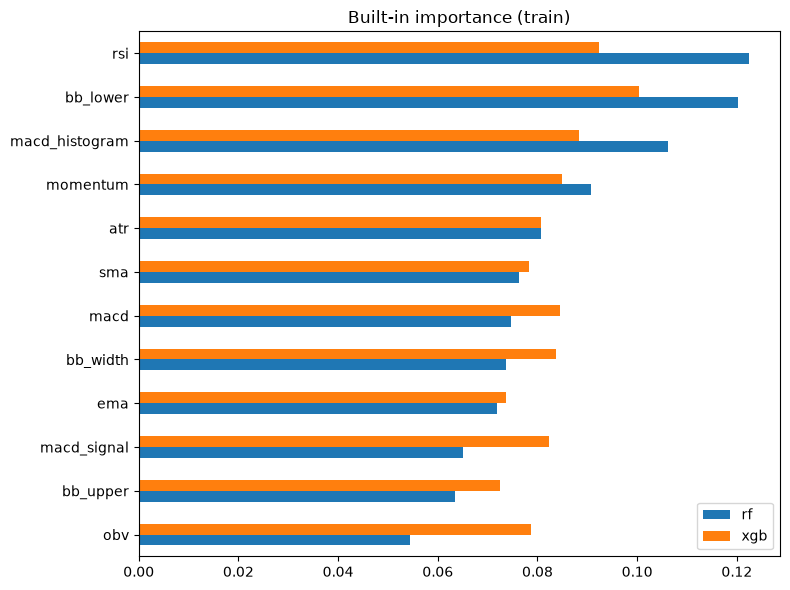

In [5]:
ax = builtin.sort_values("rf").plot.barh(figsize=(8, 6), title="Built-in importance (train)")
ax.figure.tight_layout()
ax.figure.savefig("docs/figures/builtin_importance.png", dpi=150)
plt.show()

## 2. Permutation importance (computed on validation)

In [ ]:
perm = {}
for name, model in [("rf", rf), ("xgb", xgb)]:
    r = permutation_importance(
        model, X_val, y_val,
        scoring="roc_auc",          
        n_repeats=30,
        random_state=42,
        n_jobs=-1,
    )
    perm[name] = pd.Series(r.importances_mean, index=feature_cols) 
    perm[f"{name}_std"] = pd.Series(r.importances_std, index=feature_cols)

perm = pd.DataFrame(perm)
perm["rf_signal"] = perm["rf"] > 2 * perm["rf_std"]
perm["xgb_signal"] = perm["xgb"] > 2 * perm["xgb_std"]
perm.sort_values("rf", ascending=False).round(4)

,rf,rf_std,xgb,xgb_std,rf_signal,xgb_signal
momentum,0.0131,0.0103,0.0156,0.0163,False,False
bb_upper,0.0113,0.0086,0.0060,0.0044,False,False
bb_width,0.0073,0.0147,0.0045,0.0121,False,False
bb_lower,0.0058,0.0192,-0.0105,0.0125,False,False
rsi,0.0039,0.0207,0.0179,0.0429,False,False
macd,0.0035,0.0043,0.0049,0.0116,False,False
sma,0.0035,0.0150,-0.0040,0.0096,False,False
macd_histogram,0.0019,0.0046,0.0206,0.0169,False,False
macd_signal,0.0017,0.0055,0.0155,0.0121,False,False
atr,0.0016,0.0058,-0.0001,0.0107,False,False


## 3. Random-noise probe

In [7]:
rng = np.random.default_rng(42)

X_train_probe = X_train.assign(random_noise=rng.normal(size=len(X_train)))

rf_probe = RandomForestClassifier(**rf_params).fit(X_train_probe, y_train)
probe = pd.Series(rf_probe.feature_importances_, index=X_train_probe.columns)
probe.sort_values(ascending=False).round(3)

bb_lower          0.115
rsi               0.110
macd_histogram    0.104
bb_width          0.084
momentum          0.082
macd              0.072
atr               0.067
macd_signal       0.065
obv               0.063
ema               0.062
sma               0.060
bb_upper          0.059
random_noise      0.059
dtype: float64

## 4. Feature correlation

In [8]:

corr = X_train.corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = upper.stack().dropna().sort_values(ascending=False)
pairs[pairs > 0.9].round(3)

sma       ema            0.997
ema       bb_upper       0.977
sma       bb_upper       0.977
          bb_lower       0.975
ema       bb_lower       0.968
macd      macd_signal    0.949
bb_upper  bb_lower       0.904
dtype: float64

## 5. SHAP (XGBoost, computed on validation)

In [9]:

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_val)
print(shap_values.shape)   # harus (jumlah baris val, 12)

shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols)
shap_importance.sort_values(ascending=False).round(4)

(127, 12)


rsi               0.7637
bb_lower          0.3485
macd_signal       0.3104
macd              0.2921
macd_histogram    0.2688
momentum          0.2657
ema               0.2317
sma               0.1508
bb_width          0.1451
atr               0.1301
obv               0.1248
bb_upper          0.0655
dtype: float32

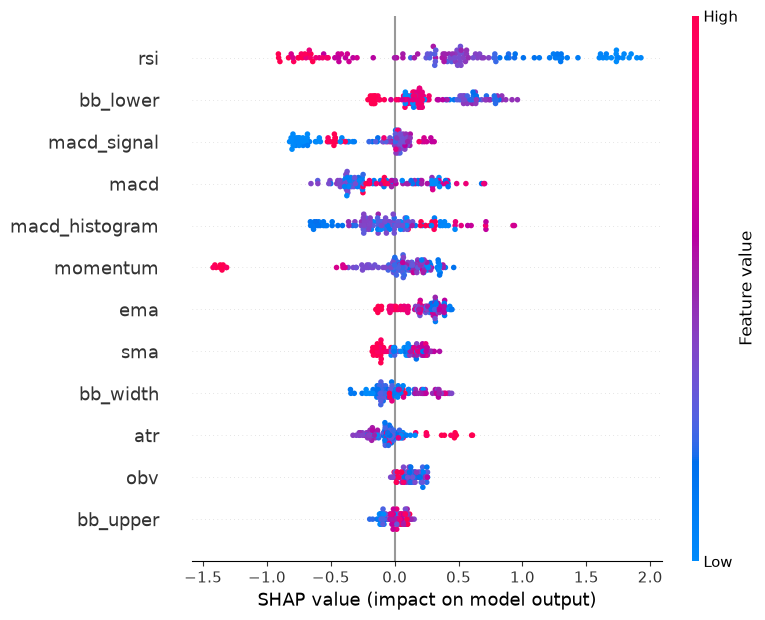

In [10]:
shap.summary_plot(shap_values, X_val, show=False)
plt.gcf().savefig("docs/figures/shap_summary_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Do the methods agree?

In [11]:
importance_table = pd.DataFrame({
    "rf_builtin": builtin["rf"],
    "xgb_builtin": builtin["xgb"],
    "rf_permutation_val": perm["rf"],
    "xgb_permutation_val": perm["xgb"],
    "xgb_shap_val": shap_importance,
})

ranks = importance_table.rank(ascending=False)
ranks["mean_rank"] = ranks.mean(axis=1)
ranks.sort_values("mean_rank").round(1)

,rf_builtin,xgb_builtin,rf_permutation_val,xgb_permutation_val,xgb_shap_val,mean_rank
rsi,1.0,2.0,5.0,2.0,1.0,2.2
momentum,4.0,4.0,1.0,3.0,6.0,3.6
macd_histogram,3.0,3.0,8.0,1.0,5.0,4.0
bb_lower,2.0,1.0,4.0,12.0,2.0,4.2
macd,7.0,5.0,6.0,6.0,4.0,5.6
macd_signal,10.0,7.0,9.0,4.0,3.0,6.6
bb_width,8.0,6.0,3.0,7.0,9.0,6.6
sma,6.0,10.0,7.0,10.0,8.0,8.2
atr,5.0,8.0,10.0,8.0,10.0,8.2
bb_upper,11.0,12.0,2.0,5.0,12.0,8.4


In [12]:
# Seberapa searah peringkat antar metode? (1 = identik, 0 = tidak berhubungan)
ranks.drop(columns="mean_rank").corr(method="spearman").round(2)

,rf_builtin,xgb_builtin,rf_permutation_val,xgb_permutation_val,xgb_shap_val
rf_builtin,1.00,0.80,0.33,0.24,0.64
xgb_builtin,0.80,1.00,0.34,0.35,0.78
rf_permutation_val,0.33,0.34,1.00,0.31,0.13
xgb_permutation_val,0.24,0.35,0.31,1.00,0.26
xgb_shap_val,0.64,0.78,0.13,0.26,1.00


In [13]:
importance_table.round(4).to_csv("docs/results/day15_importance.csv")

In [ ]:
## Observations

# RSI is the most consistent in higher ranks